# 07 — Complete End-to-End ANN Training Loop (PyTorch)

This is the central engineering notebook. We now train a real `784 → 64 → 10` ANN rather than demonstrating isolated operations.

## The training lifecycle

For each mini-batch:

1. load inputs and labels
2. forward propagation
3. compute loss
4. clear/record gradients correctly
5. backpropagate
6. optimizer update
7. accumulate metrics

At epoch boundaries we evaluate on held-out test data **without training behavior enabled**.

The training loop is shown explicitly rather than delegated to a one-line convenience API so the mechanics remain visible.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# 1) Wrap NumPy arrays in TensorDataset so features and labels stay aligned.
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)

# 2) DataLoader creates shuffled mini-batches.
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    generator=generator,
)

# 3) Keep test tensors separate because they are never used for gradient updates.
test_X = torch.tensor(X_test, dtype=torch.float32, device=device)
test_y = torch.tensor(y_test, dtype=torch.long, device=device)

class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(784, 64)
        self.activation = nn.ReLU()
        self.output = nn.Linear(64, 10)

        # Kaiming initialization is appropriate for ReLU networks.
        nn.init.kaiming_normal_(self.hidden.weight, nonlinearity='relu')
        nn.init.zeros_(self.hidden.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x):
        z1 = self.hidden(x)
        a1 = self.activation(z1)
        logits = self.output(a1)
        return logits

model = MNISTMLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    # train() enables training-time behaviour for modules such as Dropout/BatchNorm.
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # Gradients accumulate by default in PyTorch, so clear them first.
        optimizer.zero_grad(set_to_none=True)

        # Forward propagation: pixels -> hidden activations -> logits.
        logits = model(xb)

        # CrossEntropyLoss consumes raw logits and integer class labels.
        loss = loss_fn(logits, yb)

        # Backpropagation populates .grad tensors for every trainable parameter.
        loss.backward()

        # The optimizer reads gradients and updates parameters in place.
        optimizer.step()

        batch_size = xb.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_seen += batch_size

    return total_loss / total_seen, total_correct / total_seen

def evaluate(model, X, y):
    # eval() switches modules to inference behaviour.
    model.eval()
    # no_grad() prevents autograd graph construction and reduces memory usage.
    with torch.no_grad():
        logits = model(X)
        loss = loss_fn(logits, y).item()
        accuracy = (logits.argmax(dim=1) == y).float().mean().item()
    return loss, accuracy

history = []
for epoch in range(1, 9):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, loss_fn, optimizer, device
    )
    test_loss, test_acc = evaluate(model, test_X, test_y)
    history.append((epoch, train_loss, train_acc, test_loss, test_acc))
    print(
        f'epoch={epoch:02d} '
        f'train_loss={train_loss:.4f} '
        f'train_acc={train_acc:.4f} '
        f'test_loss={test_loss:.4f} '
        f'test_acc={test_acc:.4f}'
    )


device: cpu


epoch=01 train_loss=1.3973 train_acc=0.6260 test_loss=0.7005 test_acc=0.8300
epoch=02 train_loss=0.5548 train_acc=0.8584 test_loss=0.4815 test_acc=0.8720
epoch=03 train_loss=0.4171 train_acc=0.8876 test_loss=0.4330 test_acc=0.8830
epoch=04 train_loss=0.3542 train_acc=0.9016 test_loss=0.3918 test_acc=0.8880


epoch=05 train_loss=0.3123 train_acc=0.9130 test_loss=0.3678 test_acc=0.8990
epoch=06 train_loss=0.2859 train_acc=0.9182 test_loss=0.3509 test_acc=0.8940
epoch=07 train_loss=0.2579 train_acc=0.9276 test_loss=0.3377 test_acc=0.9020
epoch=08 train_loss=0.2382 train_acc=0.9336 test_loss=0.3297 test_acc=0.9000


In [3]:
print(model)
print('trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
for name, p in model.named_parameters():
    print(f'{name:20s} shape={tuple(p.shape)}')


MNISTMLP(
  (hidden): Linear(in_features=784, out_features=64, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)
trainable parameters: 50890
hidden.weight        shape=(64, 784)
hidden.bias          shape=(64,)
output.weight        shape=(10, 64)
output.bias          shape=(10,)


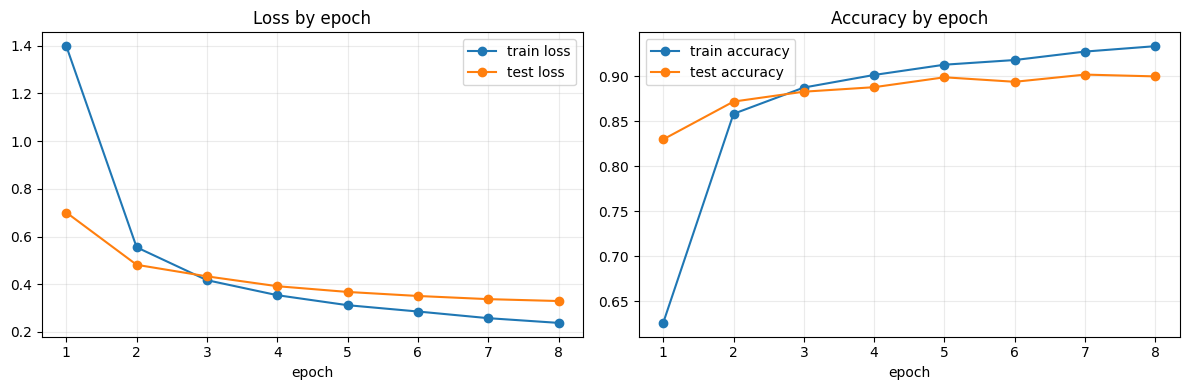

In [4]:
h = np.array(history, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h[:, 0], h[:, 1], marker='o', label='train loss')
axes[0].plot(h[:, 0], h[:, 3], marker='o', label='test loss')
axes[0].set_title('Loss by epoch')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(alpha=.25)

axes[1].plot(h[:, 0], h[:, 2], marker='o', label='train accuracy')
axes[1].plot(h[:, 0], h[:, 4], marker='o', label='test accuracy')
axes[1].set_title('Accuracy by epoch')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()


## How to read the curves

- falling training loss means the optimizer is finding parameters that better fit training data
- rising train accuracy with flat test accuracy suggests overfitting or insufficient generalization
- both curves stagnating can indicate optimization, capacity, preprocessing, or gradient-flow problems
- unstable loss can indicate a learning rate that is too high or bad numerical behavior

Business teams ultimately care about decision quality, but these curves are the first diagnostic layer explaining whether the learning system itself behaves correctly.
